In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from scipy.stats import norm
from scipy.stats import mannwhitneyu

from copy import deepcopy
import random


from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score



def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

seed_everything(0)



blue = '#0073B7'
yellow = '#FFD23F'
gray = '#7A7A7A'
purple = '#B05AA3'
green = '#00A651'
orange = '#F7941D'


blue_yellow = LinearSegmentedColormap.from_list(
    "blue_yellow", ["#0073B7", "#FFD23F"]
)


gray = '#C0C0C0'
purple = '#B05AA3'

gray_purple = LinearSegmentedColormap.from_list(
    "gray_purple",
    [gray , purple]
)

blue = '#00AEEF'
red = '#F15A2A'

In [7]:
from src.model import SSCNetwork
from src.utils.general import make_input, LatentSpace, get_ordered_indices, get_sample_from_num_swaps, get_cos_sim_torch, test_network
from network_parameters import network_parameters
from src.utils.plotting import compare_distributions_12

In [9]:
#network_parameters["regions"] = ["sen", "mtl_semantic", "mtl_sensory", "mtl", "ctx", "ctx_pointer_definition"]

#make network randomly project sensory input to obtain a wide distribution of selectivity in MTL-sensory
recording_parameters = {}
recording_parameters["regions"] = ["sen", "mtl_semantic", "mtl_sensory", "ctx", "mtl"]
recording_parameters["rate_activity"] = 1
recording_parameters["connections"] = []
recording_parameters["rate_connectivity"] = np.inf

num_episodes = 5
input_params = {}
input_params["num_days"] = 1
input_params["day_length"] = 5 * num_episodes
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 2

latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]
latent_specs["prob_list"] = [0.5/5 if i==j else 0.5/20 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)

In [10]:
def test_network(net, input_params, sleep=False, print_rate=1):
  input, input_episodes, input_latents = make_input(**input_params)
  with torch.no_grad():
    for day in range(input_params["num_days"]):
      if day%print_rate == 0:
        print(day)
      net(input[day], debug=False)
      if sleep:
        net.sleep()
  return input, input_episodes, input_latents, net

In [11]:

def episode_recall(net, ep, num_swaps):
    num_iterations = 10
    mtl_sensory_corrupted =  get_sample_from_num_swaps(ep[:net.mtl_sensory_size], num_swaps)
    mtl_0 = torch.zeros((net.mtl_size))
    mtl_0[:net.mtl_sensory_size] = mtl_sensory_corrupted
    mtl = mtl_0.clone()
    for iteration in range(num_iterations):
      mtl_hat = F.linear(net.mtl_mtl, mtl)
      mtl, _ = net.activation(mtl_hat, 'mtl')

    recall_sensory = get_cos_sim_torch(mtl[:net.mtl_sensory_size], ep[:net.mtl_sensory_size])
    recall_semantic = get_cos_sim_torch(mtl[net.mtl_sensory_size:], ep[net.mtl_sensory_size:])
    recall = get_cos_sim_torch(mtl, ep)
    return mtl_0, mtl, recall_sensory, recall_semantic, recall



def get_recalls(network):
    num_trials = 10
    recalls = []
    recalls_semantic = []
    recalls_sensory = []
    for trial in range(num_trials):
        network.init_recordings(recording_parameters)
        network.frozen = False
        network.activity_recordings_rate = 1
        network.connectivity_recordings_rate = np.inf

        input, input_episodes, input_latents, network = test_network(
            network, input_params, sleep=False, print_rate=50
        )

        for episode in torch.stack(network.activity_recordings["mtl"], axis=0):
            mtl_0, mtl, recall_sensory, recall_semantic, recall = episode_recall(network, episode, num_swaps=5)
            recalls.append(recall)
            recalls_semantic.append(recall_semantic)
            recalls_sensory.append(recall_sensory)

    return recalls, recalls_sensory, recalls_semantic

In [12]:
network_intact = torch.load("checkpoints/network_3_B.pt", weights_only=False)

In [13]:
recalls_intact = get_recalls(network_intact)

0
0
0
0
0
0
0
0
0
0


In [14]:
network_scrambled = deepcopy(network_intact)

# Generate independent permutations for each row
perms = torch.argsort(torch.rand_like(network_scrambled.mtl_semantic_ctx), dim=1)
# Apply the permutations
network_scrambled.mtl_semantic_ctx = torch.gather(network_scrambled.mtl_semantic_ctx, dim=1, index=perms)
# Freeze ctx to mtl semantic connections
network_scrambled.mtl_semantic_ctx_lmbda = 0
network_scrambled.mtl_semantic_b[:] = -1

In [15]:
recalls_scrambled = get_recalls(network_scrambled)

0
0
0
0
0
0
0
0
0
0


/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


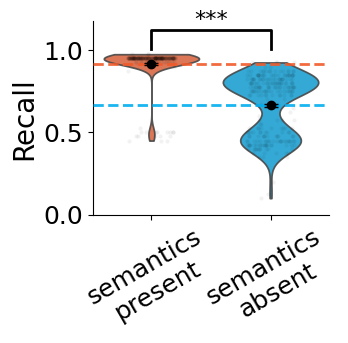

In [16]:
dist1 = ('semantics\npresent', recalls_intact[0])
dist2 = ('semantics\nabsent', recalls_scrambled[0])

palette = {
    "semantics\npresent": red, 
    "semantics\nabsent": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("Recall", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 0.5, 1], fontsize=18)
plt.tight_layout()
sns.despine()


plt.savefig('Figures_SVG/7c.svg', dpi=300, transparent=True)

In [17]:
len(recalls_intact[0])

260

# Blocked vs interleaved

In [8]:
seed_everything(0)


recording_parameters = {}
recording_parameters["regions"] = ["mtl_sensory"]
recording_parameters["rate_activity"] = 1
recording_parameters["connections"] = []
recording_parameters["rate_connectivity"] = np.inf


input_params = {}
input_params["num_days"] = 1
input_params["day_length"] = 80
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 8

latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]

In [9]:
input_params["num_days"] = 10
input_params["day_length"] = 50
input_params["mean_duration"] = 1

latent_specs["prob_list"] = [0.2 if i==0 else 0 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)

network = SSCNetwork(network_parameters, recording_parameters)
input, input_episodes, input_latents, network = test_network(network, input_params, print_rate=50)


prototype_A = torch.zeros(latent_specs["dims"][0], network.mtl_sensory_size)
replayed_A =  torch.zeros(latent_specs["dims"][0], input_params["num_days"]*network.sleep_duration_A, network.mtl_sensory_size)
prototype_B = torch.zeros(latent_specs["dims"][1], network.mtl_sensory_size)
replayed_B =  torch.zeros(latent_specs["dims"][0],  input_params["num_days"]*network.sleep_duration_A, network.mtl_sensory_size)

replayed_A[0] = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
prototype_A[0] = network.activation(torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.awake_indices].mean(axis=0), "mtl_sensory", sleep=True)[0]
network.awake_indices = []
network.sleep_indices_A = []


0


In [10]:
for k in range(1, 5):
    latent_specs["prob_list"] = [0.2 if i==k else 0 for i in range(5) for j in range(5)]
    input_params["latent_space"] = LatentSpace(**latent_specs)
    input, input_episodes, input_latents, network = test_network(network, input_params, print_rate=50)
    replayed_A[k] = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
    prototype_A[k] = network.activation(torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.awake_indices].mean(axis=0), "mtl_sensory", sleep=True)[0]
    network.awake_indices = []
    network.sleep_indices_A = []


for k in range(5):
    latent_specs["prob_list"] = [0.2 if j==k else 0 for i in range(5) for j in range(5)]
    input_params["latent_space"] = LatentSpace(**latent_specs)
    input, input_episodes, input_latents, network = test_network(network, input_params, print_rate=50)
    replayed_B[k] = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
    prototype_B[k] = network.activation(torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.awake_indices].mean(axis=0), "mtl_sensory", sleep=True)[0]
    network.awake_indices = []
    network.sleep_indices_A = []


0
0
0
0
0
0
0
0
0


In [11]:
def get_max_overlap(replayed, prototpyes):
    cos_sims = [get_cos_sim_torch(replayed, prototype) for prototype in prototpyes]
    max_sim = torch.max(torch.stack(cos_sims, dim=0))
    return max_sim.item()

In [12]:

prototypes = torch.concat([prototype_A, prototype_B], axis=0)
max_overlaps_blocked = []
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[0]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[1]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[2]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[3]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_A[4]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[0]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[1]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[2]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[3]])
max_overlaps_blocked.extend([get_max_overlap(replayed, prototypes) for replayed in replayed_B[4]])

In [16]:
recording_parameters = {}
recording_parameters["regions"] = ["mtl_semantic", "mtl_sensory", "ctx"]
recording_parameters["rate_activity"] = 1
recording_parameters["connections"] = []
recording_parameters["rate_connectivity"] = np.inf


input_params = {}
input_params["num_days"] = 200
input_params["day_length"] = 80
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 8

latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]

In [17]:
latent_specs["prob_list"] = [0.5/5 if i==j else 0.5/20 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)

network = SSCNetwork(network_parameters, recording_parameters)
input, input_episodes, input_latents, network = test_network(network, input_params, print_rate=50)


0
50
100
150


In [18]:
X_ctx = torch.stack(network.activity_recordings["ctx"], dim=0)[network.awake_indices][-100*input_params["day_length"]:]

X_latent_A = F.one_hot(input_latents[-100:, :, 0].long(), num_classes=latent_specs["dims"][0])
X_latent_B = F.one_hot(input_latents[-100:, :, 1].long(), num_classes=latent_specs["dims"][1])
X_latent_AB = torch.cat((X_latent_A, X_latent_B), axis=2)


network.selectivity_ctx, network.ordered_indices_ctx  = get_ordered_indices(X_ctx, X_latent_AB, assembly_size=10)

In [19]:
sel_blocked = network.selectivity_ctx.max(axis=1)[0]

(array([20.,  0.,  0.,  0.,  0.,  0., 10., 10., 10., 50.]),
 array([0.81527263, 0.8313154 , 0.84735817, 0.86340088, 0.87944365,
        0.89548641, 0.91152918, 0.92757195, 0.94361466, 0.95965743,
        0.9757002 ]),
 <BarContainer object of 10 artists>)

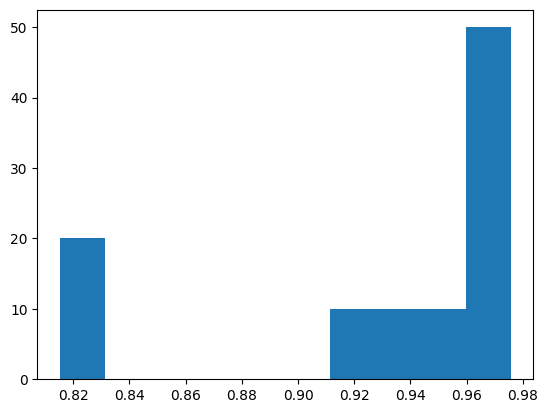

In [21]:
plt.hist(sel_blocked[:100])

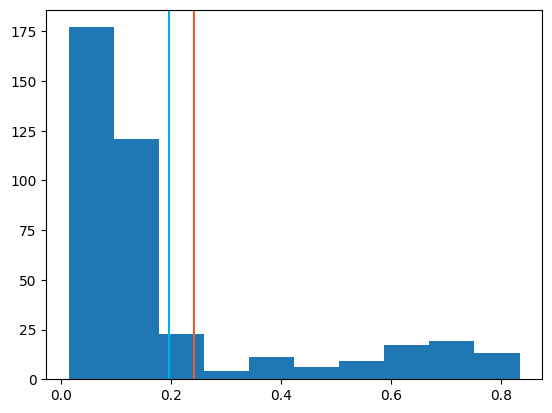

In [82]:
plt.hist(sel_interleaved)
plt.axvline(sel_blocked.mean(), color=red, label="blocked")
plt.axvline(sel_interleaved.mean(), color=blue, label="interleaved")

In [22]:
input_params["num_days"] = 100
input_params["day_length"] = 50
input_params["mean_duration"] = 1
latent_specs["prob_list"] = [1/25 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)
network = SSCNetwork(network_parameters, recording_parameters)
input, input_episodes, input_latents, network = test_network(network, input_params, print_rate=50)

0
50


In [23]:
replayed_interleaved = torch.stack(network.activity_recordings["mtl_sensory"], axis=0)[network.sleep_indices_A]
max_overlaps_interleaved = [get_max_overlap(replayed, prototypes) for replayed in replayed_interleaved]

/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


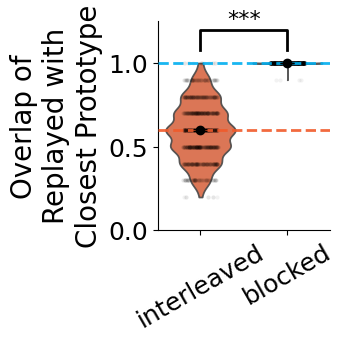

In [24]:
dist1 = ('interleaved', max_overlaps_interleaved)
dist2 = ('blocked', max_overlaps_blocked)

palette = {
    "interleaved": red,   # light blue
    "blocked": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("Overlap of\nReplayed with\nClosest Prototype", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 0.5, 1], fontsize=18)
plt.tight_layout()
sns.despine()


plt.savefig('Figures_SVG/7d.svg', dpi=300, transparent=True)

In [26]:
recording_parameters = {}
recording_parameters["regions"] = ["mtl_semantic", "mtl_sensory", "ctx"]
recording_parameters["rate_activity"] = 1
recording_parameters["connections"] = []
recording_parameters["rate_connectivity"] = np.inf


input_params = {}
input_params["num_days"] = 200
input_params["day_length"] = 80
input_params["mean_duration"] = 5
input_params["fixed_duration"] = True
input_params["num_swaps"] = 8

latent_specs = {}
latent_specs["num"] = 2
latent_specs["total_sizes"] = [50, 50]
latent_specs["act_sizes"] = [10, 10]
latent_specs["dims"] = [5, 5]

In [27]:
latent_specs["prob_list"] = [0.5/5 if i==j else 0.5/20 for i in range(5) for j in range(5)]
input_params["latent_space"] = LatentSpace(**latent_specs)

network = SSCNetwork(network_parameters, recording_parameters)
input, input_episodes, input_latents, network = test_network(network, input_params, print_rate=50)


0
50
100
150


In [28]:
X_ctx = torch.stack(network.activity_recordings["ctx"], dim=0)[network.awake_indices][-100*input_params["day_length"]:]

X_latent_A = F.one_hot(input_latents[-100:, :, 0].long(), num_classes=latent_specs["dims"][0])
X_latent_B = F.one_hot(input_latents[-100:, :, 1].long(), num_classes=latent_specs["dims"][1])
X_latent_AB = torch.cat((X_latent_A, X_latent_B), axis=2)


network.selectivity_ctx, network.ordered_indices_ctx  = get_ordered_indices(X_ctx, X_latent_AB, assembly_size=10)

In [29]:
sel_interleaved = network.selectivity_ctx.max(axis=1)[0]

/Users/albertalbesagonzalez/Documents/sensory-semantic-episodes/src/utils/plotting.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=groups, y=data, inner=None, cut=0, alpha=0.9, palette=palette)


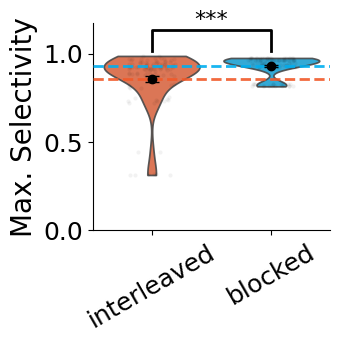

In [32]:
dist1 = ('interleaved', sel_interleaved[:100])
dist2 = ('blocked', sel_blocked[:100])

palette = {
    "interleaved": red,   # light blue
    "blocked": blue
}

compare_distributions_12(dist1, dist2, palette)
plt.ylabel("Max. Selectivity", fontsize=20)
plt.xticks(fontsize=18, rotation=30)
plt.yticks([0, 0.5, 1], fontsize=18)
plt.tight_layout()
sns.despine()


plt.savefig('Figures_SVG/7d.svg', dpi=300, transparent=True)